# Quantum Error Analysis and Visualization

Este notebook procesa ejecuciones experimentales de simulaciones cuánticas, las compara con modelos analíticos teóricos y calcula métricas de error estándar (RMSE, MSE, R2).

**Correcciones Implementadas:**
1. **Estructura restaurada**: Se recuperó la estructura original completa del notebook, incluyendo las secciones de gráficos de superficie (3D) y los subplots de mallas (10x10 y 50x50) que se habían omitido accidentalmente.
2. **Alineación de Datos**: Creación limpia de DataFrames para evitar la duplicación de índices de 0 a 19.
3. **Estandarización Independiente**: Las máscaras lógicas separan los experimentos `Noise = 0.0` y `Noise = 9.0` para que el `StandardScaler` no comprima los datos puros debido a la alta varianza del ruido.
4. **Box Plots**: Generación de subplots nativos utilizando `facet_col='Noise'` con Plotly Express.

## 1. Libraries and Modules

In [8]:
import pandas as pd
import numpy as np
from numpy import sin, cos, pi
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from sklearn.metrics import r2_score as r2, mean_absolute_error as mae, mean_squared_error as mse, root_mean_squared_error as rmse
from sklearn.preprocessing import StandardScaler

## 2. Theoretical Models

In [9]:
def rel_err(y_true,y_pred):
    return np.abs((y_true - y_pred)/y_true)

def rmse_pt(y_true,y_pred):
    return np.abs(y_true - y_pred)

def analytical(theta: float, beta: float, alpha: float):
    return (
        cos(alpha)**4 + sin(alpha)**4 +
        2 * (sin(alpha)**2) * (cos(alpha)**2) * cos(theta) +
        cos(alpha+beta)**4 + sin(alpha+beta)**4 +
        2 * (sin(alpha+beta)**2) * (cos(alpha+beta)**2) * cos(theta)
    ) / 2

def f(θ, Pt, Pϕ, ϕ):
    """
     θ  = Relative phase angle
     Pt = probability of getting the desired phased Bell's state
     Pϕ = Probability of measuring in the direction ϕ
     ϕ  = Direction of medition
    """
    return Pt * Pϕ * ( cos(ϕ)**4 + sin(ϕ)**4 + 2 * (sin(ϕ)**2) * (cos(ϕ)**2) * cos(θ) ) / 2

# ... Additional noisy models/functions (ξ, etc.) ...


## 3. Data Loading and Metric Calculation

In [10]:
# Load filenames gracefully
try:
    reviewed_probability_filenames = pd.read_csv('./runs/filenames.csv', header=None).dropna(axis=1, how='all').values.flatten()
    noisy_probability_filenames = pd.read_csv('./runs/noisy_filenames.csv', header=None).dropna(axis=1, how='all').values.flatten()
except FileNotFoundError:
    print('Warning: File lists not found. Ensure the directory paths are correct.')
    reviewed_probability_filenames, noisy_probability_filenames = [], []

N_data = 20
theta_FSS = np.linspace(0, 2*pi, N_data)
beta_angle = np.linspace(0, pi, N_data)
alpha = pi/16
path = './runs/'

# Construir el modelo analítico (Ground Truth)
model = np.array([[analytical(theta=t, beta=b, alpha=alpha) for b in beta_angle] for t in theta_FSS])

noiseless_r2, noiseless_mse, noiseless_rmse = [], [], []
noisy_r2, noisy_mse, noisy_rmse = [], [], []

# Extracción de métricas para Noise = 0.0
for name in reviewed_probability_filenames:
    exp = pd.read_csv(path + name, header=None).dropna(axis=1, how='all').values    
    noiseless_r2.append(1 - r2(y_true=model, y_pred=exp))
    noiseless_mse.append(mse(y_true=model, y_pred=exp))
    noiseless_rmse.append(rmse(y_true=model, y_pred=exp))

# Extracción de métricas para Noise = 9.0
for name in noisy_probability_filenames:
    exp = pd.read_csv(path + name, header=None).dropna(axis=1, how='all').values    
    noisy_r2.append(1 - r2(y_true=model, y_pred=exp))
    noisy_mse.append(mse(y_true=model, y_pred=exp))
    noisy_rmse.append(rmse(y_true=model, y_pred=exp))

# Array de estados
N_states_list = [1.0E3, 5.0E3, 1.0E4, 1.5E4, 2.0E4, 2.5E4, 3.0E4, 3.5E4, 4.0E4, 4.5E4]

# Ensamblaje seguro de los DataFrames utilizando diccionarios. 
df_reviewed = pd.DataFrame({
    'Noise': 0.0, 
    'R2': noiseless_r2, 
    'RMSE': noiseless_rmse, 
    'MSE': noiseless_mse, 
    'N_states': N_states_list[:len(noiseless_rmse)]
})

df_noisy = pd.DataFrame({
    'Noise': 9.0, 
    'R2': noisy_r2, 
    'RMSE': noisy_rmse, 
    'MSE': noisy_mse, 
    'N_states': N_states_list[:len(noisy_rmse)]
})

results = pd.concat([df_reviewed, df_noisy], ignore_index=True)


## 4. Independent Data Standardization
Se enmascaran los datos por grupo de ruido, se escalan individualmente para evitar fuga de varianza, y luego se unen con seguridad al DataFrame padre.

In [11]:
# Crear un DF vacío compartiendo el mismo índice
scaled_results = pd.DataFrame(index=results.index, columns=['R2 scaled', 'RMSE scaled', 'MSE scaled'])

# Crear máscaras booleanas para aislar cada experimento
mask_0 = results['Noise'] == 0.0
mask_9 = results['Noise'] == 9.0

scaler_0 = StandardScaler()
scaler_9 = StandardScaler()

# Entrenar y transformar SOLO si las máscaras contienen datos
if mask_0.any():
    scaled_results.loc[mask_0, ['R2 scaled', 'RMSE scaled', 'MSE scaled']] = scaler_0.fit_transform(results.loc[mask_0, ['R2', 'RMSE', 'MSE']])
if mask_9.any():
    scaled_results.loc[mask_9, ['R2 scaled', 'RMSE scaled', 'MSE scaled']] = scaler_9.fit_transform(results.loc[mask_9, ['R2', 'RMSE', 'MSE']])

scaled_results = scaled_results.astype(float)
results_df = pd.concat([results, scaled_results], axis=1)


## 5. Visualizing Error Trends

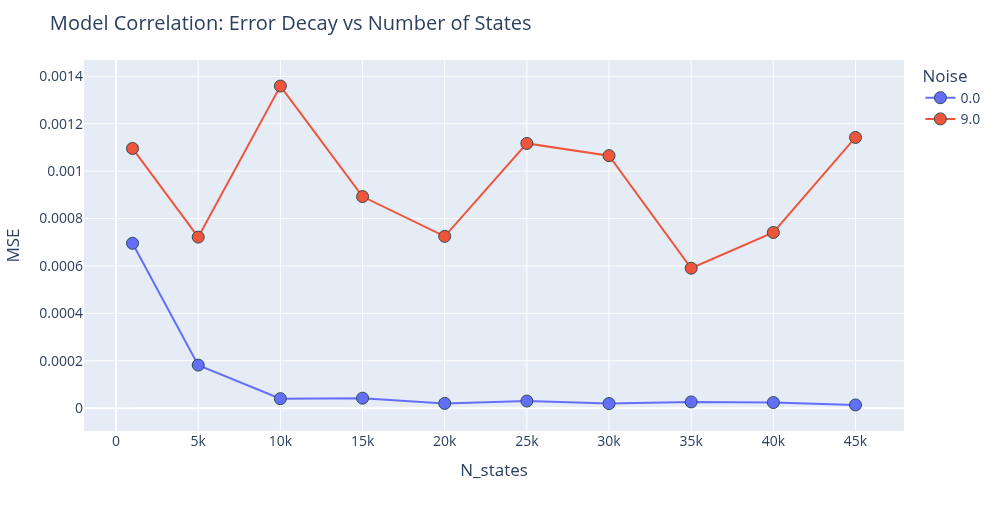

In [12]:
fig = px.line(
    results_df,
    x = 'N_states',
    y = 'MSE',
    color = 'Noise',
    markers = True
)

fig.update_traces(marker=dict(size=12, line=dict(width=1, color='DarkSlateGrey')))

fig.update_layout(
    title='Model Correlation: Error Decay vs Number of States',
    height = 500,
    width = 1000,
    font=dict(size=14)
)

fig.show()


## 6. Metric Dispersion (Box Plots with Facets)
Al usar el parámetro **`facet_col='Noise'`**, PlotlyExpress automáticamente divide los datos escalados y te genera 2 subplots comparativos.

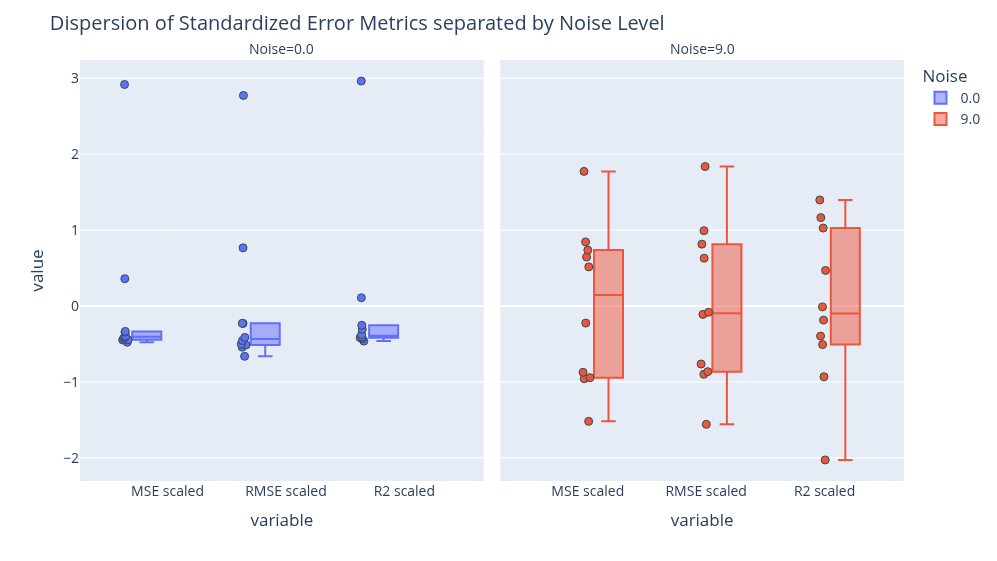

In [13]:
fig = px.box(
    results_df,
    y = ['MSE scaled', 'RMSE scaled', 'R2 scaled'],
    facet_col = 'Noise',
    color = 'Noise',
    points = 'all',
    height = 550,
    width = 1100
)

fig.update_traces(marker=dict(size=8, line=dict(width=1, color='DarkSlateGrey')), selector=dict(type='box'))

fig.update_layout(
    title='Dispersion of Standardized Error Metrics separated by Noise Level',
    font=dict(size=14),
    showlegend=True
)

fig.show()


## 7. High Error Results and Grid Comparisons

In [14]:
path = 'fixed error results/'

pure_filenames = ['pure_50x50_mesh_1E3_states_E91_data_2026_aer_simulator_25_02_2026_12_56_22',
                  'pure_50x50_mesh_5E3_states_E91_data_2026_aer_simulator_25_02_2026_14_33_00',
                  'pure_50x50_mesh_1E4_states_E91_data_2026_aer_simulator_25_02_2026_20_10_04',
                  'pure_50x50_mesh_1.5E4_states_E91_data_2026_aer_simulator_26_02_2026_15_59_56',
                  'pure_50x50_mesh_2E4_states_E91_data_2026_aer_simulator_25_02_2026_22_54_49']

error_filenames= ['50x50_mesh_1E3_states_E91_data_2026_aer_simulator_23_02_2026_18_32_14',
                  '50x50_mesh_5E3_states_E91_data_2026_aer_simulator_23_02_2026_14_22_55',
                  '50x50_mesh_1E4_estates_E91_data_2026_aer_simulator_23_02_2026_14_36_26',
                  '50x50_mesh_1.5E4_states_E91_data_2026_aer_simulator_23_02_2026_23_12_07',
                  '50x50_mesh_2E4_states_E91_data_2026_aer_simulator_24_02_2026_07_12_29',
                  '50x50_mesh_2.5E4_states_E91_data_2026_aer_simulator_24_02_2026_11_27_03']

test_filenames= ['10x10_mesh_1E3_E91_data_2026_aer_simulator_02_03_2026_15_36_28',
                 '10x10_mesh_1E4_states_E91_data_2026_aer_simulator_02_03_2026_16_23_52',
                 '10x10_mesh_1.5E4_states_E91_data_2026_aer_simulator_02_03_2026_19_08_36',
                 '10x10_mesh_2E4_states_E91_data_2026_aer_simulator_02_03_2026_19_41_56',
                 '10x10_mesh_2.5E4_states_E91_data_2026_aer_simulator_02_03_2026_19_04_56',
                 '10x10_3E4_states_E91_data_2026_aer_simulator_02_03_2026_15_54_44',
                 '10x10_mesh_3.5E4_states_E91_data_2026_aer_simulator_03_03_2026_00_58_08',
                 '10x10_mesh_4E4_states_E91_data_2026_aer_simulator_03_03_2026_00_58_51']


In [15]:
correlation_10_error = []
correlation_50_error = []
correlation_50_pure = []
alpha = pi/16

try:
    for experiment_name in test_filenames:
        experiment = pd.read_csv(path+experiment_name+'.csv', header=None).dropna(axis=1,how='all').values    
        model_10_error = np.array([[analytical(theta=t,beta=b, alpha=alpha) for b in np.linspace(0,pi,10)] for t in np.linspace(0,2*pi,10)])
        correlation_10_error.append( rmse(y_true=model_10_error,y_pred=experiment) )
        
    for experiment_name in error_filenames:
        experiment = pd.read_csv(path+experiment_name+'.csv', header=None).dropna(axis=1,how='all').values
        model_50_error = np.array([[analytical(theta=t,beta=b, alpha=alpha) for b in np.linspace(0,pi,50)] for t in np.linspace(0,2*pi,50)])
        correlation_50_error.append( rmse(y_true=model_50_error,y_pred=experiment) )
        
    for experiment_name in pure_filenames:
        experiment = pd.read_csv(path+experiment_name+'.csv', header=None).dropna(axis=1,how='all').values
        model_50_pure = np.array([[analytical(theta=t,beta=b, alpha=alpha) for b in np.linspace(0,pi,50)] for t in np.linspace(0,2*pi,50)])
        correlation_50_pure.append( rmse(y_true=model_50_pure,y_pred=experiment) )
except FileNotFoundError:
    pass

df_50_pure  = pd.DataFrame( dict(zip(['Nstates','RMSE'],[[1E3,1E4,1.5E4,2E4,2.5E4],correlation_50_pure])) )
df_50_error = pd.DataFrame( dict(zip(['Nstates','RMSE'],[[1E3,5E3,1E4,1.5E4,2E4,2.5E4],correlation_50_error])) )
df_10_error = pd.DataFrame( dict(zip(['Nstates','RMSE'],[[1E3,1E4,1.5E4,2E4,2.5E4,3E4,3.5E4,4E4],correlation_10_error])) )


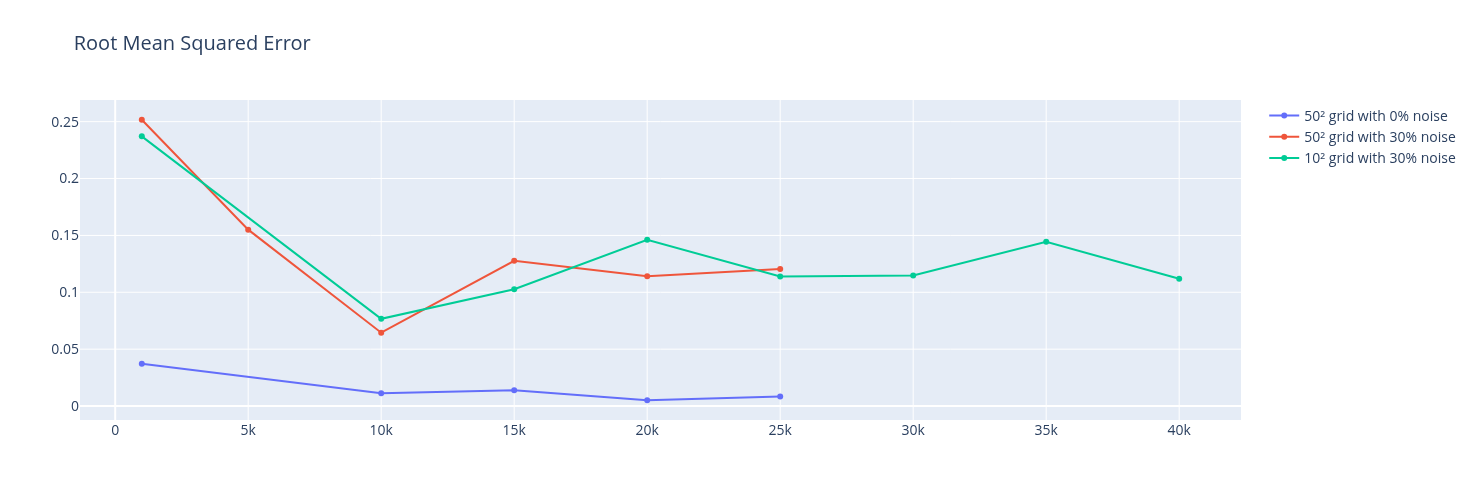

In [16]:
fig = make_subplots(rows=1, cols=1)

if not df_50_pure.empty:
    fig.add_trace(go.Scatter(x=df_50_pure['Nstates'], y=df_50_pure['RMSE'], mode='lines+markers', name='50² grid with 0% noise'), row=1, col=1)
if not df_50_error.empty:
    fig.add_trace(go.Scatter(x=df_50_error['Nstates'], y=df_50_error['RMSE'], mode='lines+markers', name='50² grid with 30% noise'), row=1, col=1)
if not df_10_error.empty:
    fig.add_trace(go.Scatter(x=df_10_error['Nstates'], y=df_10_error['RMSE'], mode='lines+markers', name='10² grid with 30% noise'), row=1, col=1)

fig.update_layout(height=500, width=889, title_text="Root Mean Squared Error", font=dict(size=14))
fig.show()


## 8. 3D Surface Comparisons
Función parametrizada para visualizar la matriz teórica superpuesta y contrastada en 3D contra una matriz de resultados.

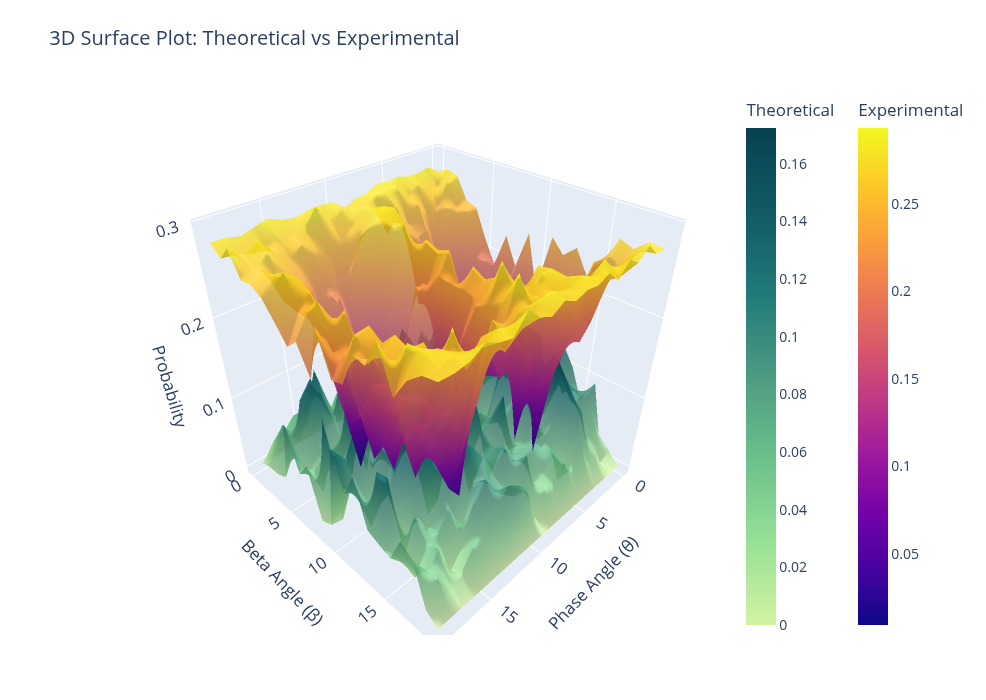

In [17]:
def plot_surface_from_csv(array_theoretical, array_experimental):
    fig = go.Figure()
    
    fig.add_trace(go.Surface(
        z=array_theoretical, 
        colorscale='Emrld',
        opacity=0.8,
        name='Theoretical',
        colorbar=dict(title='Theoretical', x=0.9)
    ))
    
    fig.add_trace(go.Surface(
        z=array_experimental, 
        opacity=0.8, 
        name='Experimental',
        colorbar=dict(title='Experimental', x=1.05)
    ))
    
    fig.update_layout(
        title='3D Surface Plot: Theoretical vs Experimental',
        autosize=False,
        width=900,
        height=700,
        margin=dict(l=65, r=50, b=65, t=90),
        scene=dict(
            xaxis_title='Phase Angle (θ)',
            yaxis_title='Beta Angle (β)',
            zaxis_title='Probability'
        ),
        font=dict(size=14) 
    )
    fig.show()

# Ejemplo de uso renderizando archivos experimentales específicos:
try:
    experiment_noiseless = pd.read_csv('./runs/3_E91_data_20x20_mesh_1.5E+04_states_AER_SIM_14_03_2026_18_45_25.csv', header=None).dropna(axis=1,how='all').values
    experiment_noisy = pd.read_csv('./runs/3_NOISY_20x20_mesh_1.5E+04_states_AER_SIM_19_03_2026_09_56_15.csv', header=None).dropna(axis=1,how='all').values
    
    model_surface = np.array([[analytical(theta=t,beta=b, alpha=pi/16) for b in np.linspace(0,pi,20)] for t in np.linspace(0,2*pi,20)])
    
    plot_surface_from_csv(
        np.sqrt(np.abs(np.square(model_surface) - np.square(experiment_noiseless))), 
        np.sqrt(np.abs(np.square(model_surface) - np.square(experiment_noisy)))
    )
except FileNotFoundError:
    pass
